# Ventilator Pressure Prediction

**Dataset:** https://www.kaggle.com/competitions/ventilator-pressure-prediction/data?select=train.csv

**Objective:**

Predicting the ventilator pressure trough a ventilator simulation that connected to a sedated patient's lung using various deep learning method, which entails:

- MLP + BiLSTM: Multi-Layer Perceptrons  + Bidirectional Long Short-Term
- BiLSTM + BiGRU: Bidirectional Long Short-Term + Bidirectional Gated Recurrent Unit
- Multi-Scale CNN + Bidirectional Long Short-Term (BiLSTM)

## **1. Import Libraries**

In [ ]:
import os, gc, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from sklearn.model_selection import GroupKFold
from transformers import get_linear_schedule_with_warmup


NUM_CPU     = os.cpu_count() or 2
NUM_WORKERS = min(NUM_CPU, 4)
torch.set_num_threads(NUM_CPU)
torch.set_num_interop_threads(2)
print(f'CPU cores available : {NUM_CPU}')
print(f'DataLoader workers  : {NUM_WORKERS}')
print(f'PyTorch threads     : {torch.get_num_threads()}')


def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark     = True

seed_everything(42)
DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_AMP   = DEVICE == 'cuda'
print(f'Device: {DEVICE} | AMP (mixed precision): {USE_AMP}')

CPU cores available : 2
DataLoader workers  : 2
PyTorch threads     : 2
Device: cuda | AMP (mixed precision): True


## **2. Load & Overview Data**

In [ ]:
import pandas as pd
import gdown

def download_and_load(file_id):
    url = f'https://drive.google.com/uc?id={file_id}'
    output = f'{file_id}.csv'
    gdown.download(url, output, quiet=False)
    return pd.read_csv(output)

df_train = download_and_load('1DmR480RMxEMn8IpahjWrf30WLm6yWFXs')
df_test  = download_and_load('1QT1ub8OfRd8vZcnPHnGK9GfVHQRFf58y')
sub      = download_and_load('1TGayZka85SeV0TpaFcpKlSY6RVCoOz4l')

print("Columns in Train:", df_train.columns.tolist())

Downloading...
From (original): https://drive.google.com/uc?id=1DmR480RMxEMn8IpahjWrf30WLm6yWFXs
From (redirected): https://drive.google.com/uc?id=1DmR480RMxEMn8IpahjWrf30WLm6yWFXs&confirm=t&uuid=ccf7add1-dd4d-432b-8aa0-32051b769623
To: /content/1DmR480RMxEMn8IpahjWrf30WLm6yWFXs.csv
100%|██████████| 440M/440M [00:06<00:00, 67.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1QT1ub8OfRd8vZcnPHnGK9GfVHQRFf58y
From (redirected): https://drive.google.com/uc?id=1QT1ub8OfRd8vZcnPHnGK9GfVHQRFf58y&confirm=t&uuid=92a5c5b9-3eb9-417d-ab07-b7092847d568
To: /content/1QT1ub8OfRd8vZcnPHnGK9GfVHQRFf58y.csv
100%|██████████| 220M/220M [00:02<00:00, 93.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1TGayZka85SeV0TpaFcpKlSY6RVCoOz4l
To: /content/1TGayZka85SeV0TpaFcpKlSY6RVCoOz4l.csv
100%|██████████| 39.1M/39.1M [00:00<00:00, 151MB/s]


Columns in Train: ['id', 'breath_id', 'R', 'C', 'time_step', 'u_in', 'u_out', 'pressure']


In [ ]:
print(df_train.head())
print(df_train.columns)

   id  breath_id   R   C  time_step       u_in  u_out   pressure
0   1          1  20  50   0.000000   0.083334      0   5.837492
1   2          1  20  50   0.033652  18.383041      0   5.907794
2   3          1  20  50   0.067514  22.509278      0   7.876254
3   4          1  20  50   0.101542  22.808822      0  11.742872
4   5          1  20  50   0.135756  25.355850      0  12.234987
Index(['id', 'breath_id', 'R', 'C', 'time_step', 'u_in', 'u_out', 'pressure'], dtype='object')


In [ ]:
def add_features(df):
    df = df.copy().sort_values(['breath_id', 'time_step']).reset_index(drop=True)

    g = df.groupby('breath_id')

    df['cumsum_u_in'] = g['u_in'].cumsum()
    df['u_in_diff1']  = g['u_in'].diff().fillna(0)
    df['u_in_diff2']  = g['u_in_diff1'].diff().fillna(0)
    df['u_in_lag1']   = g['u_in'].shift(1).fillna(0)
    df['u_in_lag2']   = g['u_in'].shift(2).fillna(0)
    df['RC']          = df['R'] * df['C']

    # Faster time_norm: avoid lambda by using min/max directly
    t_min = g['time_step'].transform('min')
    t_max = g['time_step'].transform('max')
    df['time_norm'] = (df['time_step'] - t_min) / (t_max - t_min + 1e-9)

    return df

df_train = add_features(df_train)
df_test  = add_features(df_test)

FEATURE_COLS = [
    'R', 'C', 'RC',
    'u_in', 'u_out',
    'cumsum_u_in',
    'u_in_diff1', 'u_in_diff2',
    'u_in_lag1', 'u_in_lag2',
    'time_norm'
]
INPUT_DIM = len(FEATURE_COLS)
print(f'Input features ({INPUT_DIM}): {FEATURE_COLS}')
print(f'Train breaths: {df_train["breath_id"].nunique():,}')
print(f'Test  breaths: {df_test["breath_id"].nunique():,}')

Input features (11): ['R', 'C', 'RC', 'u_in', 'u_out', 'cumsum_u_in', 'u_in_diff1', 'u_in_diff2', 'u_in_lag1', 'u_in_lag2', 'time_norm']
Train breaths: 75,450
Test  breaths: 50,300


## **3. Data Cleaning**

In [ ]:
# Missing value

def clean_ventilator(df, is_train=True, verbose=True):
    original_shape = df.shape
    tag = 'TRAIN' if is_train else 'TEST'

    null_counts = df.isnull().sum()
    null_cols   = null_counts[null_counts > 0]

    if verbose:
        if len(null_cols) == 0:
            print(f'[{tag}] Missing values: NONE ✓')
        else:
            print(f'[{tag}] Missing values found:')
            print(null_cols.to_string())

    if len(null_cols) > 0:
        id_cols = ['id', 'breath_id', 'time_step']
        id_nulls = [c for c in id_cols if c in null_cols.index]
        if id_nulls:
            before = len(df)
            df = df.dropna(subset=id_nulls)
            if verbose:
                print(f'  Dropped {before - len(df)} rows with null id/breath_id/time_step')

        const_cols = ['R', 'C']
        for col in [c for c in const_cols if c in null_cols.index]:
            df[col] = df.groupby('breath_id')[col].transform(
                lambda x: x.ffill().bfill()
            )
            if verbose:
                print(f'  Filled nulls in {col} via forward/back fill within breath')

        ts_cols = ['u_in', 'u_out', 'pressure'] if is_train else ['u_in', 'u_out']
        for col in [c for c in ts_cols if c in null_cols.index]:
            df[col] = df.groupby('breath_id')[col].transform(
                lambda x: x.interpolate(method='linear').ffill().bfill()
            )
            if verbose:
                print(f'  Interpolated nulls in {col} within each breath')

        remaining_nulls = df.isnull().sum().sum()
        if remaining_nulls > 0:
            before = len(df)
            df = df.dropna()
            if verbose:
                print(f'  Dropped {before - len(df)} rows with unfixable nulls')

    # Duplicated rows

    n_exact_dupes = df.duplicated().sum()
    n_key_dupes   = df.duplicated(subset=['breath_id', 'time_step']).sum()

    if verbose:
        print(f'[{tag}] Exact duplicate rows     : {n_exact_dupes}')
        print(f'[{tag}] Duplicate breath+timestep: {n_key_dupes}')

    if n_exact_dupes > 0:
        df = df.drop_duplicates()
        if verbose:
            print(f'  Dropped {n_exact_dupes} exact duplicates')

    if n_key_dupes > 0:
        df = df.drop_duplicates(subset=['breath_id', 'time_step'], keep='first')
        if verbose:
            print(f'  Dropped {n_key_dupes} duplicate breath+timestep rows')

# Outlier Handling
    if is_train and 'pressure' in df.columns:
        df['RC_group'] = df['R'].astype(int).astype(str) + '_' + df['C'].astype(int).astype(str)
        total_clipped  = 0

        for grp_name, grp_df in df.groupby('RC_group'):
            p    = grp_df['pressure']
            q1   = p.quantile(0.01)
            q99  = p.quantile(0.99)
            iqr  = q99 - q1
            low  = q1  - 1.5 * iqr
            high = q99 + 1.5 * iqr

            outlier_mask   = (df['RC_group'] == grp_name) & (
                (df['pressure'] < low) | (df['pressure'] > high)
            )
            n_outliers = outlier_mask.sum()
            total_clipped += n_outliers

            df.loc[outlier_mask & (df['pressure'] < low),  'pressure'] = low
            df.loc[outlier_mask & (df['pressure'] > high), 'pressure'] = high

            if verbose and n_outliers > 0:
                print(f'  RC={grp_name}: clipped {n_outliers} pressure outliers '
                      f'to [{low:.2f}, {high:.2f}]')

        df = df.drop(columns=['RC_group'])

        if verbose:
            if total_clipped == 0:
                print(f'[{tag}] Outliers (pressure): NONE ✓')
            else:
                print(f'[{tag}] Total pressure values clipped: {total_clipped} '
                      f'({100*total_clipped/len(df):.3f}% of rows)')

    bad_u_out = ~df['u_out'].isin([0, 1])
    if bad_u_out.sum() > 0:
        if verbose:
            print(f'[{tag}] WARNING: {bad_u_out.sum()} rows have u_out not in {{0,1}} — clipping')
        df['u_out'] = df['u_out'].clip(0, 1).round()

    bad_u_in = (df['u_in'] < 0) | (df['u_in'] > 100)
    if bad_u_in.sum() > 0:
        if verbose:
            print(f'[{tag}] WARNING: {bad_u_in.sum()} rows have u_in outside [0,100] — clipping')
        df['u_in'] = df['u_in'].clip(0, 100)

    if verbose:
        print(f'\n[{tag}] Shape: {original_shape} → {df.shape}')
        removed = original_shape[0] - df.shape[0]
        print(f'[{tag}] Rows removed: {removed} ({100*removed/original_shape[0]:.3f}%)')
        print(f'[{tag}] Cleaning complete ✓\n')

    return df


df_train = clean_ventilator(df_train, is_train=True,  verbose=True)
df_test  = clean_ventilator(df_test,  is_train=False, verbose=True)


[TRAIN] Missing values: NONE ✓
[TRAIN] Exact duplicate rows     : 0
[TRAIN] Duplicate breath+timestep: 0
[TRAIN] Outliers (pressure): NONE ✓

[TRAIN] Shape: (6036000, 15) → (6036000, 15)
[TRAIN] Rows removed: 0 (0.000%)
[TRAIN] Cleaning complete ✓

[TEST] Missing values: NONE ✓
[TEST] Exact duplicate rows     : 0
[TEST] Duplicate breath+timestep: 0

[TEST] Shape: (4024000, 14) → (4024000, 14)
[TEST] Rows removed: 0 (0.000%)
[TEST] Cleaning complete ✓



## **4. Data Preparation**

In [ ]:
class VentilatorDataset(Dataset):
    def __init__(self, df, feature_cols=FEATURE_COLS):
        if 'pressure' not in df.columns:
            df = df.copy()
            df['pressure'] = 0.0

        grp = df.groupby('breath_id').agg(list).reset_index()

        self.pressures = np.array(grp['pressure'].tolist(), dtype=np.float32)
        self.u_outs    = np.array(grp['u_out'].tolist(),    dtype=np.float32)

        feat_arrays = [np.array(grp[c].tolist(), dtype=np.float32) for c in feature_cols]
        self.inputs = np.stack(feat_arrays, axis=1).transpose(0, 2, 1)  # (N, 80, F)

    def __len__(self):
        return len(self.pressures)

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.inputs[idx]),     # (80, F)
            torch.from_numpy(self.u_outs[idx]),     # (80,)
            torch.from_numpy(self.pressures[idx]),  # (80,)
        )


class VentilatorLoss(nn.Module):
    def forward(self, preds, targets, u_out):
        w = 1.0 - u_out
        return (w * (targets - preds).abs()).sum(-1) / (w.sum(-1) + 1e-9)


def compute_metric(pressures, u_outs, preds):
    w = 1 - u_outs
    return float((w * np.abs(pressures - preds)).sum() / (w.sum() + 1e-9))


print('Dataset, loss, metric ready.')

Dataset, loss, metric ready.


## **5. Model: Multi-Layer Perceptrons (MLP) + Bidirectional Long Short-Term (BiLSTM) as Baseline**

In [ ]:
class MLPBiLSTM(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, dense_dim=128, lstm_dim=128, logit_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, dense_dim),
            nn.LayerNorm(dense_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(dense_dim, dense_dim * 2),
            nn.LayerNorm(dense_dim * 2),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(
            input_size=dense_dim * 2,
            hidden_size=lstm_dim,
            num_layers=1,            # was 2
            batch_first=True,
            bidirectional=True,
        )
        self.head = nn.Sequential(
            nn.Linear(lstm_dim * 2, logit_dim),
            nn.ReLU(),
            nn.Linear(logit_dim, 1)
        )

    def forward(self, x):
        x = self.mlp(x)
        x, _ = self.lstm(x)
        return self.head(x).squeeze(-1)


m = MLPBiLSTM()
print(f'Model 1 — MLP+BiLSTM  | Params: {sum(p.numel() for p in m.parameters()):,}')
del m

Model 1 — MLP+BiLSTM  | Params: 463,617


## **6. Model: Bidirectional Long Short-Term (BiLSTM) + Bidirectional Gated Recurrent Unit (BiGRU)**

In [ ]:
class BiLSTMBiGRU(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, dense_dim=128, lstm_dim=128, gru_dim=128, logit_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, dense_dim),
            nn.LayerNorm(dense_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(dense_dim, dense_dim * 2),
            nn.LayerNorm(dense_dim * 2),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(
            input_size=dense_dim * 2, hidden_size=lstm_dim,
            num_layers=1, batch_first=True, bidirectional=True
        )
        self.gru = nn.GRU(
            input_size=lstm_dim * 2, hidden_size=gru_dim,
            num_layers=1, batch_first=True, bidirectional=True
        )
        self.residual_proj = nn.Linear(lstm_dim * 2, gru_dim * 2)
        self.head = nn.Sequential(
            nn.Linear(gru_dim * 2, logit_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(logit_dim, 1)
        )

    def forward(self, x):
        x = self.mlp(x)
        lstm_out, _ = self.lstm(x)
        gru_out,  _ = self.gru(lstm_out)
        return self.head(gru_out + self.residual_proj(lstm_out)).squeeze(-1)


m = BiLSTMBiGRU()
print(f'Model 2 — BiLSTM+BiGRU | Params: {sum(p.numel() for p in m.parameters()):,}')
del m

Model 2 — BiLSTM+BiGRU | Params: 825,857


## **7. Model: Multi-Scale CNN + Bidirectional Long Short-Term (BiLSTM)**

In [ ]:
class MultiScaleCNNBiLSTM(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, cnn_channels=64, lstm_dim=128,
                 logit_dim=128, kernels=(3, 7, 11)):
        super().__init__()
        self.cnn_branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(input_dim, cnn_channels, k, padding=k//2, bias=False),
                nn.BatchNorm1d(cnn_channels), nn.ReLU(), nn.Dropout(0.1),
                nn.Conv1d(cnn_channels, cnn_channels, k, padding=k//2, bias=False),
                nn.BatchNorm1d(cnn_channels), nn.ReLU(),
            ) for k in kernels
        ])
        self.lstm = nn.LSTM(
            input_size=cnn_channels * len(kernels),
            hidden_size=lstm_dim,
            num_layers=1, batch_first=True, bidirectional=True
        )
        self.head = nn.Sequential(
            nn.Linear(lstm_dim * 2, logit_dim), nn.ReLU(),
            nn.Dropout(0.1), nn.Linear(logit_dim, 1)
        )

    def forward(self, x):
        xc = x.permute(0, 2, 1)                          # (B, F, 80)
        x  = torch.cat([b(xc) for b in self.cnn_branches], dim=1).permute(0, 2, 1)
        x, _ = self.lstm(x)
        return self.head(x).squeeze(-1)


m = MultiScaleCNNBiLSTM()
print(f'Model 3 — CNN+BiLSTM  | Params: {sum(p.numel() for p in m.parameters()):,}')
del m

Model 3 — CNN+BiLSTM  | Params: 464,321


## **8. Training Preparation**
 Speed improvements:
  1. batch_size 128 → 512  — fewer Python iterations per epoch
 2. persistent_workers=True — workers stay alive between epochs
     (avoids paying worker spawn cost every epoch)
3. prefetch_factor=2 — each worker pre-loads 2 batches ahead
4. Mixed precision (AMP) — halves memory + compute on GPU
      gracefully disabled on CPU (USE_AMP=False)
5. Early stopping — stops after patience epochs of no improvement
      instead of always running all 50 epochs
6. optimizer.zero_grad(set_to_none=True) — faster than zero_grad()

In [ ]:
def worker_init_fn(worker_id):
    np.random.seed(np.random.get_state()[1][0] + worker_id)


def fit_model(
    model,
    train_dataset,
    val_dataset,
    epochs=50,
    batch_size=512,
    lr=1e-3,
    warmup_prop=0.05,
    patience=7,
    device=DEVICE,
    verbose=10,
):
    loss_fn   = VentilatorLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scaler    = GradScaler("cuda", enabled=USE_AMP)


    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, drop_last=True,
        num_workers=NUM_WORKERS, pin_memory=(device == 'cuda'),
        worker_init_fn=worker_init_fn,
        persistent_workers=(NUM_WORKERS > 0),
        prefetch_factor=2 if NUM_WORKERS > 0 else None,
    )
    val_loader = DataLoader(
        val_dataset, batch_size=512, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(device == 'cuda'),
        persistent_workers=(NUM_WORKERS > 0),
        prefetch_factor=2 if NUM_WORKERS > 0 else None,
    )

    n_steps  = epochs * len(train_loader)
    n_warmup = int(warmup_prop * n_steps)
    scheduler = get_linear_schedule_with_warmup(optimizer, n_warmup, n_steps)

    history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
    best_mae, best_preds, patience_counter = float('inf'), None, 0

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        train_loss = 0.0
        for x, u_out, p in train_loader:
            x, u_out, p = x.to(device), u_out.to(device), p.to(device)
            optimizer.zero_grad(set_to_none=True)
            with autocast(device_type=DEVICE, enabled=USE_AMP):
                pred = model(x).squeeze(-1)
                loss = loss_fn(pred, p, u_out).mean()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            train_loss += loss.item() / len(train_loader)

        # Validate
        model.eval()
        val_loss, preds_list = 0.0, []
        with torch.no_grad():
            for x, u_out, p in val_loader:
                x, u_out, p = x.to(device), u_out.to(device), p.to(device)
                with autocast(device_type=DEVICE, enabled=USE_AMP):
                    pred = model(x).squeeze(-1)
                    val_loss += loss_fn(pred, p, u_out).mean().item() / len(val_loader)
                preds_list.append(pred.cpu().float().numpy())

        preds_np = np.concatenate(preds_list, 0)
        val_mae  = compute_metric(val_dataset.pressures, val_dataset.u_outs, preds_np)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mae'].append(val_mae)

        if val_mae < best_mae:
            best_mae, best_preds, patience_counter = val_mae, preds_np.copy(), 0
        else:
            patience_counter += 1

        if epoch % verbose == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{epochs} | train={train_loss:.4f} | '
                  f'val={val_loss:.4f} | mae={val_mae:.4f} | '
                  f'lr={scheduler.get_last_lr()[0]:.2e} | '
                  f'patience={patience_counter}/{patience}')

        # Early stopping
        if patience_counter >= patience:
            print(f'  Early stop at epoch {epoch} (no improvement for {patience} epochs)')
            break

    return best_preds, history


def predict_model(model, dataset, batch_size=512, device=DEVICE):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=NUM_WORKERS,
                        persistent_workers=(NUM_WORKERS > 0),
                        prefetch_factor=2 if NUM_WORKERS > 0 else None)
    preds = []
    with torch.no_grad():
        for x, u_out, p in loader:
            with autocast(device_type=DEVICE, enabled=USE_AMP):
                pred = model(x.to(device)).squeeze(-1)
            preds.append(pred.cpu().float().numpy())
    return np.concatenate(preds, 0)


def run_kfold(
    model_cls, model_kwargs, df, df_test,
    n_splits=5,
    selected_folds=(0,),
    epochs=50,
    batch_size=512,
    lr=1e-3,
    patience=7,
    device=DEVICE,
):
    gkf      = GroupKFold(n_splits=n_splits)
    splits   = list(gkf.split(df, df, groups=df['breath_id']))
    fold_maes, preds_test, all_histories = [], [], []
    test_ds  = VentilatorDataset(df_test)

    for fold_idx, (tr_idx, val_idx) in enumerate(splits):
        if fold_idx not in selected_folds:
            continue
        print(f'\n── Fold {fold_idx+1}/{n_splits} ──────────────────────────')
        seed_everything(42 + fold_idx)

        model  = model_cls(**model_kwargs).to(device)
        tr_ds  = VentilatorDataset(df.iloc[tr_idx].reset_index(drop=True))
        val_ds = VentilatorDataset(df.iloc[val_idx].reset_index(drop=True))

        print(f'  Train: {len(tr_ds):,} | Val: {len(val_ds):,} | '
              f'Params: {sum(p.numel() for p in model.parameters()):,}')

        best_preds_val, history = fit_model(
            model, tr_ds, val_ds,
            epochs=epochs, batch_size=batch_size,
            lr=lr, patience=patience, device=device
        )

        fold_mae = compute_metric(val_ds.pressures, val_ds.u_outs, best_preds_val)
        fold_maes.append(fold_mae)
        all_histories.append(history)
        print(f'  Best Val MAE (fold {fold_idx+1}): {fold_mae:.4f}')

        preds_test.append(predict_model(model, test_ds, device=device))

        del model, tr_ds, val_ds
        gc.collect()
        if device == 'cuda':
            torch.cuda.empty_cache()

    cv_mae = float(np.mean(fold_maes))
    print(f'\n>>> CV MAE ({len(fold_maes)} folds): {cv_mae:.4f} ± {np.std(fold_maes):.4f}')
    return {
        'fold_maes': fold_maes,
        'cv_mae':    cv_mae,
        'cv_std':    float(np.std(fold_maes)),
        'pred_test': np.mean(preds_test, 0),
        'histories': all_histories,
    }


print('Training engine ready.')

Training engine ready.


## **9. Train All The Model**

In [ ]:
TRAIN_CONFIG = dict(
    n_splits       = 5,
    selected_folds = (0,),
    epochs         = 50,
    batch_size     = 512,
    lr             = 1e-3,
    patience       = 7,
    device         = DEVICE,
)

results = {}

print('=' * 60)
print('TRAINING MODEL 1: MLP + BiLSTM (Baseline)')
print('=' * 60)
results['MLP+BiLSTM'] = run_kfold(
    MLPBiLSTM,
    dict(input_dim=INPUT_DIM, dense_dim=128, lstm_dim=128, logit_dim=128),
    df_train, df_test, **TRAIN_CONFIG
)

print('\n' + '=' * 60)
print('TRAINING MODEL 2: BiLSTM + BiGRU Stack')
print('=' * 60)
results['BiLSTM+BiGRU'] = run_kfold(
    BiLSTMBiGRU,
    dict(input_dim=INPUT_DIM, dense_dim=128, lstm_dim=128, gru_dim=128, logit_dim=128),
    df_train, df_test, **TRAIN_CONFIG
)

print('\n' + '=' * 60)
print('TRAINING MODEL 3: Multi-Scale CNN + BiLSTM')
print('=' * 60)
results['CNN+BiLSTM'] = run_kfold(
    MultiScaleCNNBiLSTM,
    dict(input_dim=INPUT_DIM, cnn_channels=64, lstm_dim=128, logit_dim=128),
    df_train, df_test, **TRAIN_CONFIG
)

print('\n✓ All models trained.')

TRAINING MODEL 1: MLP + BiLSTM (Baseline)

── Fold 1/5 ──────────────────────────
  Train: 60,360 | Val: 15,090 | Params: 463,617
  Epoch   1/50 | train=12.5885 | val=5.5651 | mae=5.5968 | lr=4.01e-04 | patience=0/7
  Epoch  10/50 | train=1.6607 | val=1.7034 | mae=1.7139 | lr=8.42e-04 | patience=1/7
  Epoch  20/50 | train=1.1751 | val=1.3288 | mae=1.3357 | lr=6.32e-04 | patience=1/7
  Epoch  30/50 | train=1.0449 | val=0.9809 | mae=0.9846 | lr=4.21e-04 | patience=0/7
  Epoch  40/50 | train=0.9226 | val=0.8873 | mae=0.8904 | lr=2.11e-04 | patience=1/7
  Epoch  50/50 | train=0.8476 | val=0.8170 | mae=0.8200 | lr=0.00e+00 | patience=1/7
  Best Val MAE (fold 1): 0.8199

>>> CV MAE (1 folds): 0.8199 ± 0.0000

TRAINING MODEL 2: BiLSTM + BiGRU Stack

── Fold 1/5 ──────────────────────────
  Train: 60,360 | Val: 15,090 | Params: 825,857
  Epoch   1/50 | train=10.6814 | val=3.7932 | mae=3.8161 | lr=4.01e-04 | patience=0/7
  Epoch  10/50 | train=1.7368 | val=1.7516 | mae=1.7593 | lr=8.42e-04 | pa

## **10. Evaluation Matrix**

In [ ]:
MODEL_REGISTRY = {
    'MLP+BiLSTM':   (MLPBiLSTM,           dict(input_dim=INPUT_DIM, dense_dim=128, lstm_dim=128, logit_dim=128)),
    'BiLSTM+BiGRU': (BiLSTMBiGRU,         dict(input_dim=INPUT_DIM, dense_dim=128, lstm_dim=128, gru_dim=128, logit_dim=128)),
    'CNN+BiLSTM':   (MultiScaleCNNBiLSTM, dict(input_dim=INPUT_DIM, cnn_channels=64, lstm_dim=128, logit_dim=128)),
}

rows = []
for name, res in results.items():
    fold_maes  = res['fold_maes']
    best_epoch = int(np.mean([np.argmin(h['val_mae']) + 1 for h in res['histories']]))
    cls, kwargs = MODEL_REGISTRY[name]
    params = sum(p.numel() for p in cls(**kwargs).parameters())
    rows.append({
        'Model':            name,
        'CV MAE ↓':         round(res['cv_mae'], 4),
        'CV Std ↓':         round(res['cv_std'], 4),
        'Best Fold MAE ↓':  round(min(fold_maes), 4),
        'Worst Fold MAE ↓': round(max(fold_maes), 4),
        'Parameters':       f'{params:,}',
        'Best Epoch ↓':     best_epoch,
        '_params_raw':      params,
    })

eval_df = pd.DataFrame(rows)
eval_df['_rank_mae']    = eval_df['CV MAE ↓'].rank()
eval_df['_rank_std']    = eval_df['CV Std ↓'].rank()
eval_df['_rank_params'] = eval_df['_params_raw'].rank()
eval_df['Composite Rank'] = (
    eval_df['_rank_mae'] * 3.0 + eval_df['_rank_std'] * 1.0 + eval_df['_rank_params'] * 0.5
).round(1)

display_cols = ['Model','CV MAE ↓','CV Std ↓','Best Fold MAE ↓',
                'Worst Fold MAE ↓','Parameters','Best Epoch ↓','Composite Rank']
display_df   = eval_df[display_cols].sort_values('Composite Rank')

print('=' * 80)
print('EVALUATION MATRIX  (↓ = lower is better)')
print('=' * 80)
print(display_df.to_string(index=False))
print(f'\n>>> BEST MODEL: {display_df.iloc[0]["Model"]} (CV MAE = {display_df.iloc[0]["CV MAE ↓"]})')

EVALUATION MATRIX  (↓ = lower is better)
       Model  CV MAE ↓  CV Std ↓  Best Fold MAE ↓  Worst Fold MAE ↓ Parameters  Best Epoch ↓  Composite Rank
  CNN+BiLSTM    0.6848       0.0           0.6848            0.6848    464,321            50             6.0
BiLSTM+BiGRU    0.7246       0.0           0.7246            0.7246    825,857            50             9.5
  MLP+BiLSTM    0.8199       0.0           0.8199            0.8199    463,617            49            11.5

>>> BEST MODEL: CNN+BiLSTM (CV MAE = 0.6848)


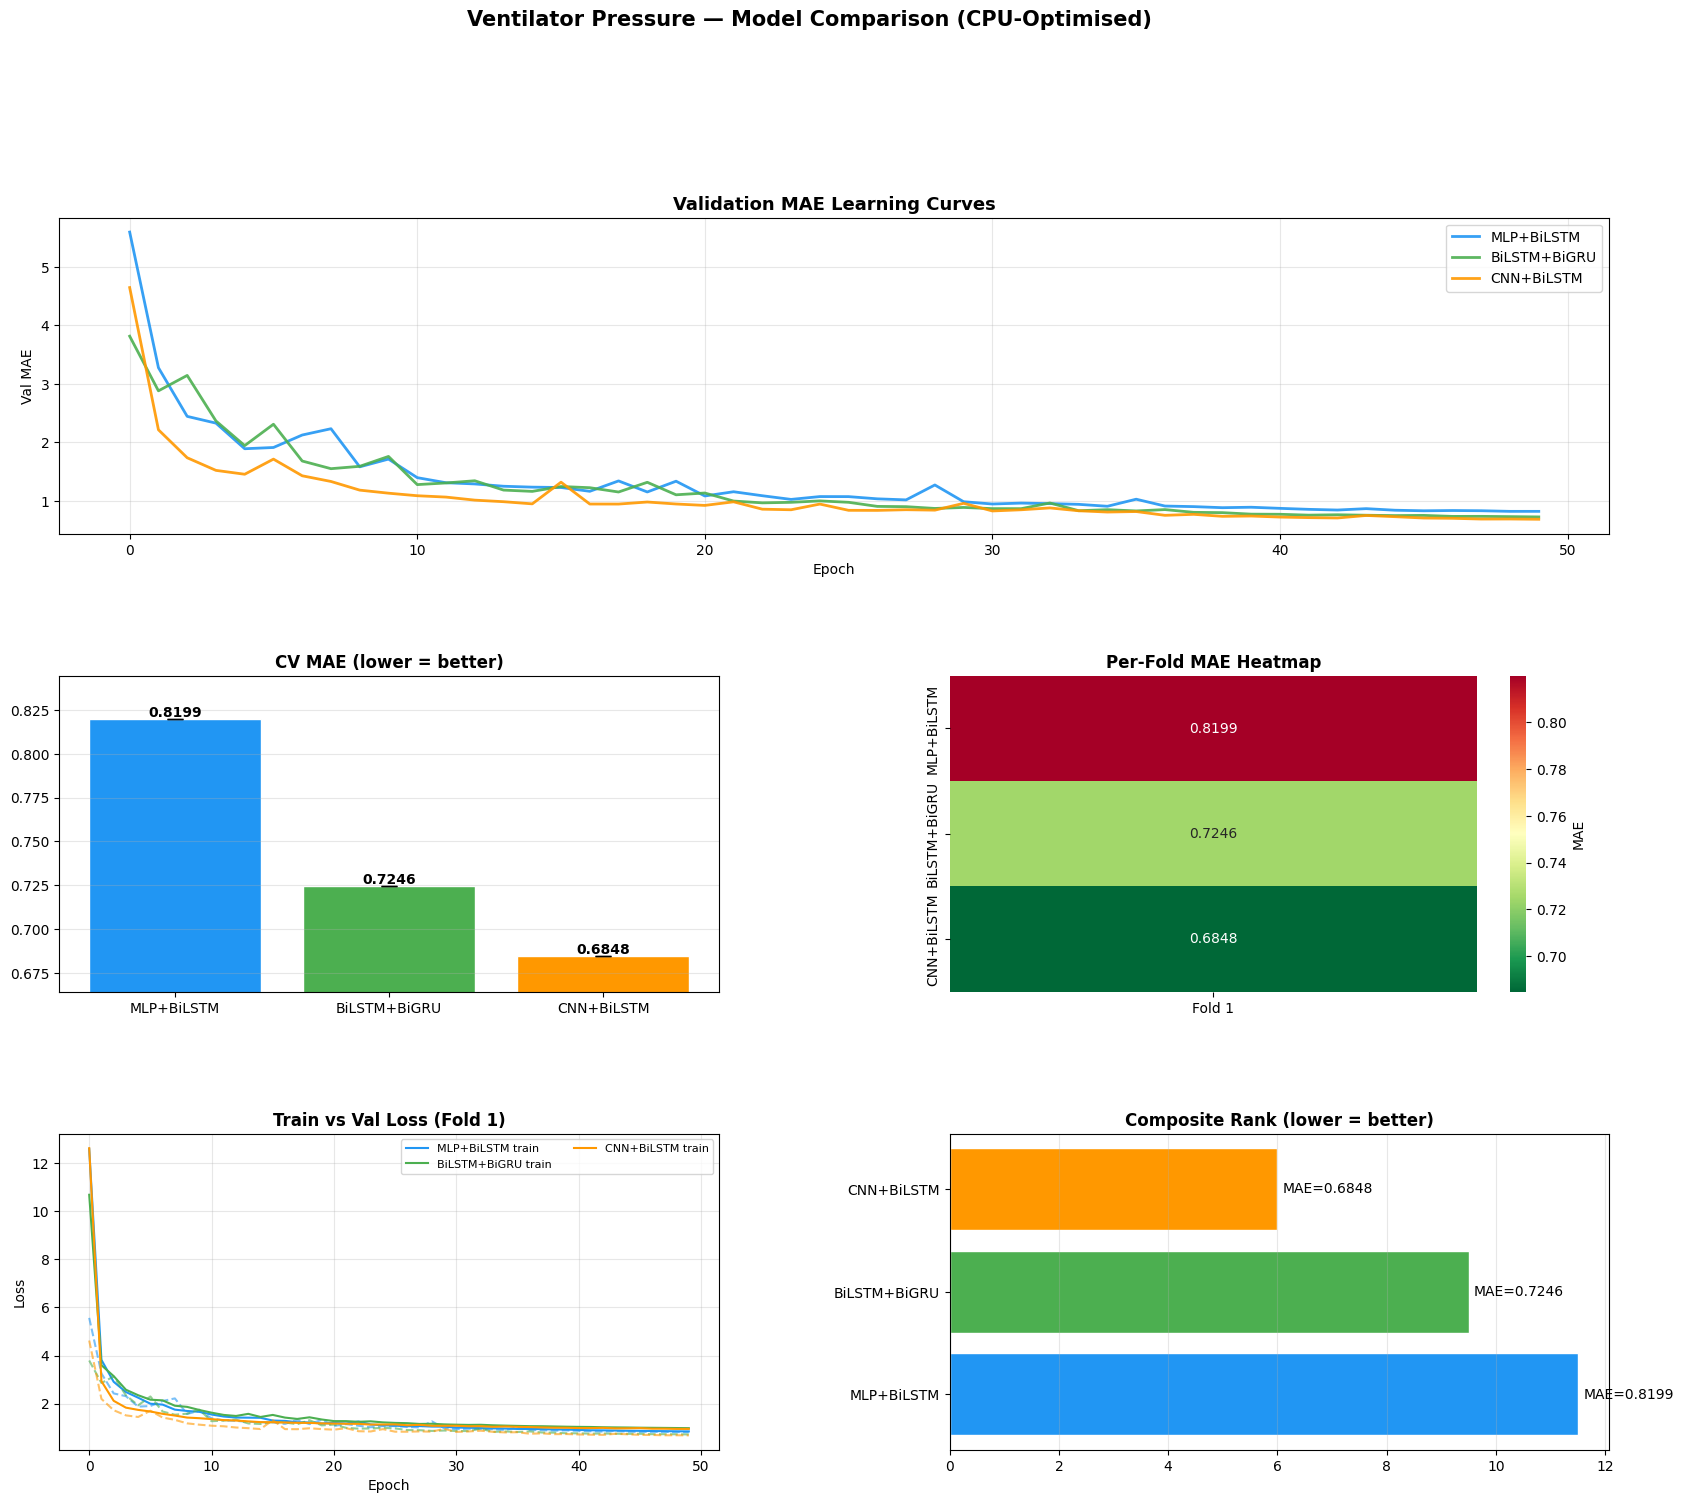

Saved: model_comparison.png


In [ ]:
COLORS = {
    'MLP+BiLSTM':   '#2196F3',
    'BiLSTM+BiGRU': '#4CAF50',
    'CNN+BiLSTM':   '#FF9800',
    'TCN':          '#E91E63',
}

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# Learning curves
ax1 = fig.add_subplot(gs[0, :])
for name, res in results.items():
    for fi, hist in enumerate(res['histories']):
        ax1.plot(hist['val_mae'], color=COLORS[name],
                 alpha=0.9 if fi == 0 else 0.4,
                 linewidth=2 if fi == 0 else 1,
                 label=name if fi == 0 else None)
ax1.set_title('Validation MAE Learning Curves', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val MAE')
ax1.legend(); ax1.grid(True, alpha=0.3)

# CV MAE bar
ax2 = fig.add_subplot(gs[1, 0])
names = list(results.keys())
maes  = [results[n]['cv_mae'] for n in names]
stds  = [results[n]['cv_std'] for n in names]
bars  = ax2.bar(names, maes, yerr=stds, capsize=6,
                color=[COLORS[n] for n in names], edgecolor='white')
for bar, mae in zip(bars, maes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{mae:.4f}', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('CV MAE (lower = better)', fontsize=12, fontweight='bold')
ax2.set_ylim(min(maes) * 0.97, max(maes) * 1.03)
ax2.grid(True, axis='y', alpha=0.3)

# Fold heatmap
ax3 = fig.add_subplot(gs[1, 1])
fold_matrix = np.array([results[n]['fold_maes'] for n in names])
sns.heatmap(fold_matrix, annot=True, fmt='.4f', cmap='RdYlGn_r',
            xticklabels=[f'Fold {i+1}' for i in range(fold_matrix.shape[1])],
            yticklabels=names, ax=ax3, cbar_kws={'label': 'MAE'})
ax3.set_title('Per-Fold MAE Heatmap', fontsize=12, fontweight='bold')

# Train vs val loss
ax4 = fig.add_subplot(gs[2, 0])
for name, res in results.items():
    hist = res['histories'][0]
    ax4.plot(hist['train_loss'], color=COLORS[name], label=f'{name} train')
    ax4.plot(hist['val_loss'],   color=COLORS[name], linestyle='--', alpha=0.6)
ax4.set_title('Train vs Val Loss (Fold 1)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Epoch'); ax4.set_ylabel('Loss')
ax4.legend(fontsize=8, ncol=2); ax4.grid(True, alpha=0.3)

# Composite rank
ax5 = fig.add_subplot(gs[2, 1])
sd = display_df.sort_values('Composite Rank')
ax5.barh(sd['Model'], sd['Composite Rank'],
         color=[COLORS[n] for n in sd['Model']], edgecolor='white')
for i, (_, row) in enumerate(sd.iterrows()):
    ax5.text(row['Composite Rank'] + 0.1, i,
             f"MAE={row['CV MAE ↓']:.4f}", va='center', fontsize=10)
ax5.set_title('Composite Rank (lower = better)', fontsize=12, fontweight='bold')
ax5.invert_yaxis(); ax5.grid(True, axis='x', alpha=0.3)

plt.suptitle('Ventilator Pressure — Model Comparison (CPU-Optimised)',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: model_comparison.png')

## **11. Breath Predictions**

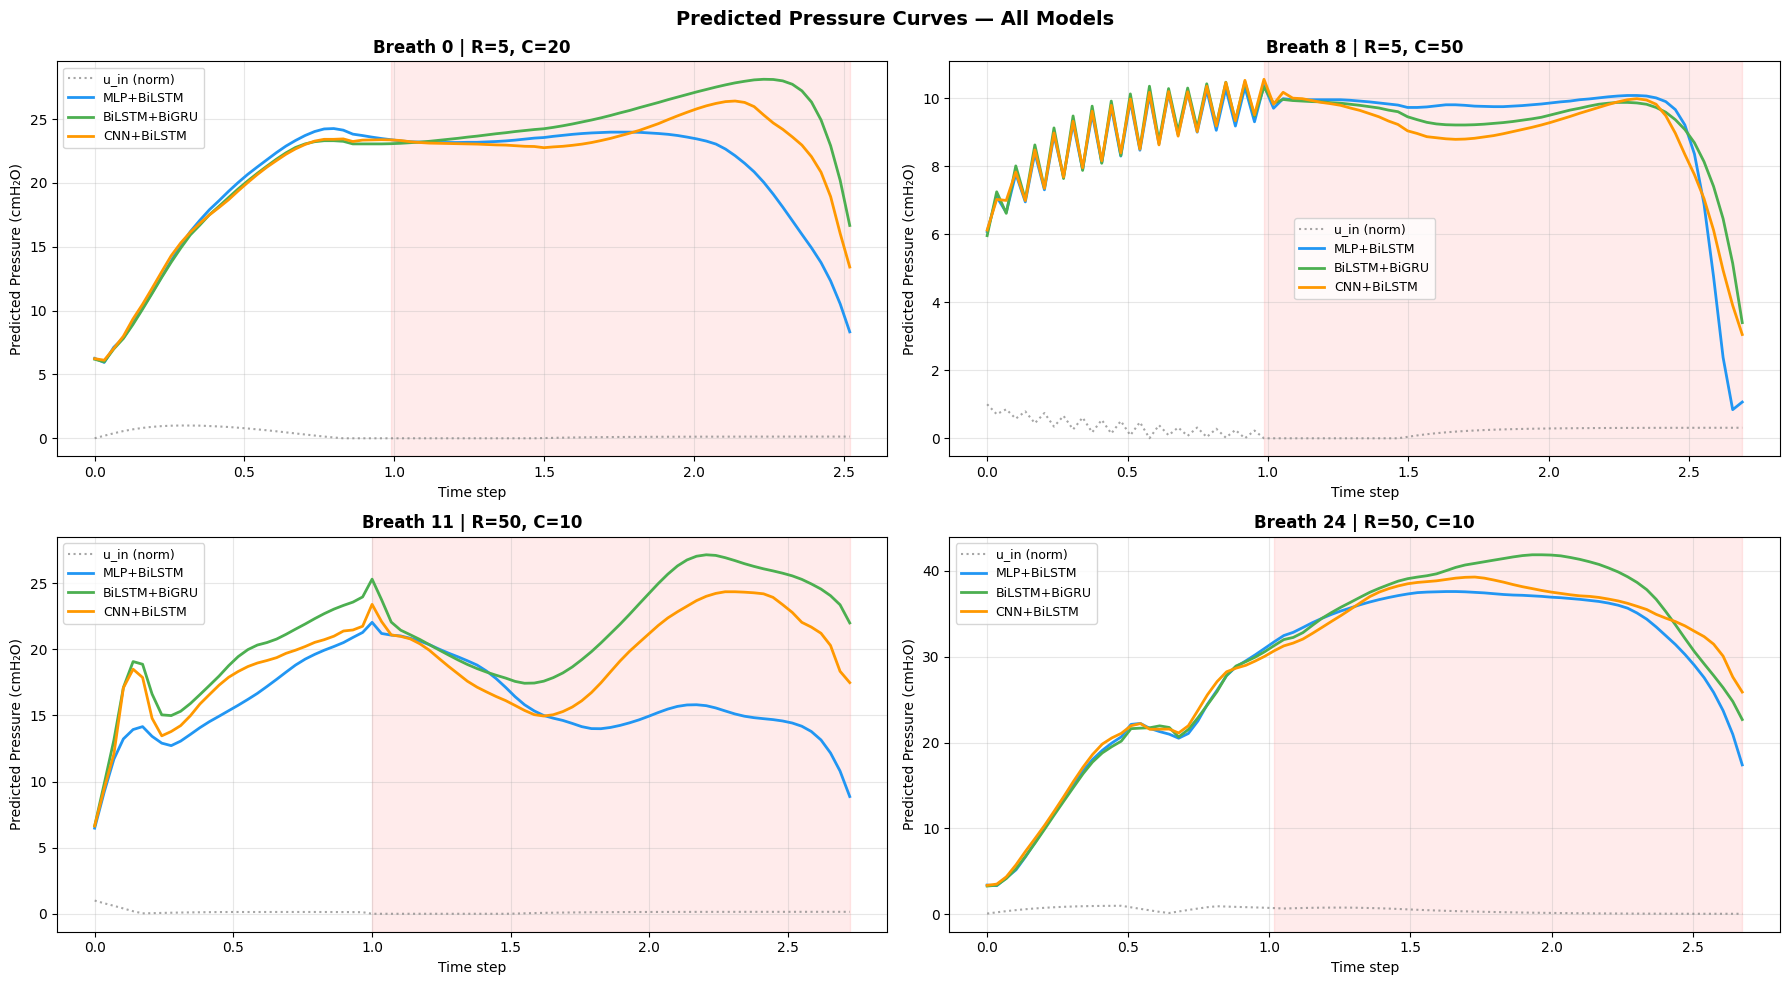

In [ ]:
sample_ids  = df_test['breath_id'].unique()[:4]
all_test_ids = list(df_test['breath_id'].unique())

fig, axes = plt.subplots(2, 2, figsize=(18, 10), squeeze=False)
axes = axes.flatten()

for ax_i, breath_id in enumerate(sample_ids):
    df_b       = df_test[df_test['breath_id'] == breath_id].reset_index(drop=True)
    time_steps = df_b['time_step'].values
    u_in       = df_b['u_in'].values
    u_out      = df_b['u_out'].values
    breath_pos = all_test_ids.index(breath_id)

    ax = axes[ax_i]
    ax.plot(time_steps, u_in / (u_in.max() + 1e-9),
            color='grey', linewidth=1.5, linestyle=':', label='u_in (norm)', alpha=0.7)

    for name, res in results.items():
        ax.plot(time_steps, res['pred_test'][breath_pos],
                color=COLORS[name], linewidth=2, label=name)

    ax.set_title(f'Breath {breath_id} | R={df_b["R"].iloc[0]}, C={df_b["C"].iloc[0]}',
                 fontweight='bold')
    ax.set_xlabel('Time step'); ax.set_ylabel('Predicted Pressure (cmH₂O)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    exp_mask = u_out == 1
    if exp_mask.any():
        ax.axvspan(time_steps[exp_mask][0], time_steps[-1],
                   alpha=0.08, color='red', label='Expiratory')

plt.suptitle('Predicted Pressure Curves — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **12. Final Summary**

In [ ]:
best_model_name = display_df.iloc[0]['Model']
print(f'Generating submission from: {best_model_name}')

best_pred_test = results[best_model_name]['pred_test']
breath_ids = df_test.groupby('breath_id').apply(lambda x: x.index.tolist()).reset_index()
breath_ids.columns = ['breath_id', 'row_indices']

pred_flat = np.zeros(len(df_test))
for i, (_, row) in enumerate(breath_ids.iterrows()):
    if i < len(best_pred_test):
        pred_flat[row['row_indices']] = best_pred_test[i]

sub['pressure'] = pred_flat
sub.to_csv('submission.csv', index=False)
print(f'submission.csv saved — shape: {sub.shape}')

print('\n' + '=' * 60)
print('FINAL SUMMARY')
print('=' * 60)
print(display_df[['Model','CV MAE ↓','CV Std ↓','Parameters','Composite Rank']].to_string(index=False))
print(f'\nSubmission from : {best_model_name}')
print(f'Expected score  : ~{display_df.iloc[0]["CV MAE ↓"]}')

Generating submission from: CNN+BiLSTM
submission.csv saved — shape: (4024000, 2)

FINAL SUMMARY
       Model  CV MAE ↓  CV Std ↓ Parameters  Composite Rank
  CNN+BiLSTM    0.6848       0.0    464,321             6.0
BiLSTM+BiGRU    0.7246       0.0    825,857             9.5
  MLP+BiLSTM    0.8199       0.0    463,617            11.5

Submission from : CNN+BiLSTM
Expected score  : ~0.6848
